# 7/13/23 -- freezing here i think

In [1]:
from src.MPOptoClass import *
from src.utils.utils import *

import mat73
import pynapple as nap
import numpy as np
import matplotlib.pyplot as plt

%load_ext autoreload 
%autoreload 2
%matplotlib widget

In [2]:
session_path = '../data/vgat2_06062023'
#preprocess_path = f'{session_path}/preprocess'
session = MPOptoClass(session_path)

love


# lets select threshold neurons based on FR during climbing

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


(71, 3383000)
(132, 3383000)


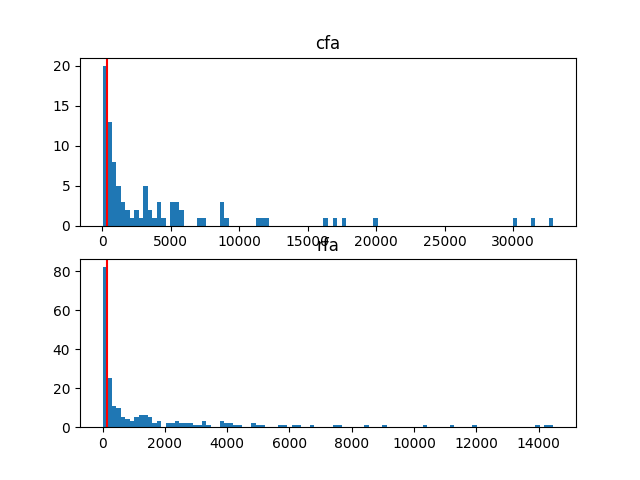

In [3]:
session.CFA_FR_climbing = session.CFA_FR[:, session.climbing_logical]
session.RFA_FR_climbing = session.RFA_FR[:, session.climbing_logical]

session.CFA_FR_climbsum = np.sum(session.CFA_FR_climbing, 1)
session.RFA_FR_climbsum = np.sum(session.RFA_FR_climbing, 1)

nada, CFA_bins = np.histogram(session.CFA_FR_climbsum, bins=100)
nada, RFA_bins = np.histogram(session.RFA_FR_climbsum, bins=100)

CFA_thresh = CFA_bins[1]
RFA_thresh = RFA_bins[1]


fig3, (ax30, ax31) = plt.subplots(2, 1)
ax30.hist(session.CFA_FR_climbsum, bins=100)
ax30.axvline(CFA_thresh, color='r')
ax30.set_title('cfa')

ax31.hist(session.RFA_FR_climbsum, bins=100)
ax31.axvline(RFA_thresh, color='r')
ax31.set_title('rfa')

session.CFA_highFR = session.CFA_FR[session.CFA_FR_climbsum > CFA_thresh, :]
session.RFA_highFR = session.RFA_FR[session.RFA_FR_climbsum > RFA_thresh, :]

print(session.CFA_highFR.shape)
print(session.RFA_highFR.shape)

# lets take (thresholded) FRs and put into control/laser trials

In [4]:
num_trials = session.num_trials
trial_length = session.trial_length

CFA_highFR_trials = session.CFA_highFR[:, session.trial_logical]
RFA_highFR_trials = session.RFA_highFR[:, session.trial_logical]

session.CFA_highFR_trials = np.stack([CFA_highFR_trials[:, trial_length*i:trial_length*(i+1)] for i in range(num_trials)], axis=-1)
session.RFA_highFR_trials = np.stack([RFA_highFR_trials[:, trial_length*i:trial_length*(i+1)] for i in range(num_trials)], axis=-1)

# sanity checks! 

num_CFA = session.CFA_highFR_trials.shape[0]
num_RFA = session.RFA_highFR_trials.shape[0]
num_timesteps = session.CFA_highFR_trials.shape[1]
num_trials = session.CFA_highFR_trials.shape[2]

print(f'num CFA neurons: {num_CFA}')
print(f'num RFA neurons: {num_RFA}')
print(f'num timesteps: {num_timesteps}')
print(f'num trials: {num_trials}')

num CFA neurons: 71
num RFA neurons: 132
num timesteps: 120
num trials: 46


In [5]:
num_ctrltrials = session.num_ctrl_trials
trial_length = session.trial_length

CFA_ctrl_trials = session.CFA_highFR[:, session.ctrl_trial_logical]
RFA_ctrl_trials = session.RFA_highFR[:, session.ctrl_trial_logical]

session.CFA_ctrl_trials = np.stack([CFA_ctrl_trials[:, trial_length*i:trial_length*(i+1)] for i in range(num_ctrltrials)], axis=-1)
session.RFA_ctrl_trials = np.stack([RFA_ctrl_trials[:, trial_length*i:trial_length*(i+1)] for i in range(num_ctrltrials)], axis=-1)

# sanity checks! 

num_ctrl_trials = session.CFA_ctrl_trials.shape[2]

print(f'num ctrl trials: {num_ctrl_trials}')

num ctrl trials: 44


# lets take neuron-averaged, trial averaged OPTO vs CTRL trials

## ERROR BARS ARE SEM BUT THEY DON'T TAKE INTO ACCT ERROR FROM NEURON AVERAGING

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


Text(0.5, 1.0, 'RFA neuron/trial avged')

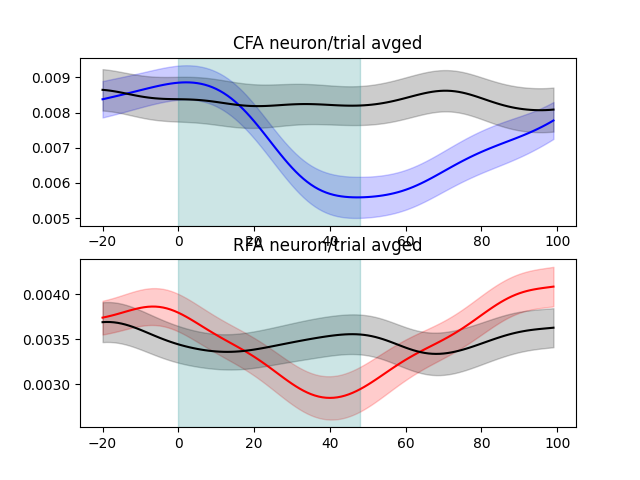

In [6]:
session.CFA_avgavg = np.average(session.CFA_highFR_trials, axis=(0,2))
temp = np.average(session.CFA_highFR_trials, axis=0)
session.CFA_sem = np.std(temp, axis=1) / np.sqrt(num_trials)

session.CFA_ctrl_avgavg = np.average(session.CFA_ctrl_trials, axis=(0,2))
temp = np.average(session.CFA_ctrl_trials, axis=0)
session.CFA_ctrlsem = np.std(temp, axis=1) / np.sqrt(num_ctrl_trials)

session.RFA_avgavg = np.average(session.RFA_highFR_trials, axis=(0,2))
temp = np.average(session.RFA_highFR_trials, axis=0)
session.RFA_sem = np.std(temp, axis=1) / np.sqrt(num_trials)

session.RFA_ctrl_avgavg = np.average(session.RFA_ctrl_trials, axis=(0,2))
temp = np.average(session.RFA_ctrl_trials, axis=0)
session.RFA_ctrlsem = np.std(temp, axis=1) / np.sqrt(num_ctrl_trials)

x = np.arange(-20,100)

fig71, (ax71_0, ax71_1) = plt.subplots(2, 1)
ax71_0.plot(x, session.CFA_avgavg, color='blue')
ax71_0.plot(x, session.CFA_ctrl_avgavg, color='black')
ax71_0.fill_between(x, session.CFA_avgavg - session.CFA_sem, session.CFA_avgavg + session.CFA_sem, color='blue', alpha=0.2)
ax71_0.fill_between(x, session.CFA_ctrl_avgavg - session.CFA_ctrlsem, session.CFA_ctrl_avgavg + session.CFA_ctrlsem, color='black', alpha=0.2)
ax71_0.axvspan(0, 48, color='teal', alpha=0.2)
ax71_0.set_title('CFA neuron/trial avged')

ax71_1.plot(x, session.RFA_avgavg, color='red')
ax71_1.plot(x, session.RFA_ctrl_avgavg, color='black')
ax71_1.fill_between(x, session.RFA_avgavg - session.RFA_sem, session.RFA_avgavg + session.RFA_sem, color='red', alpha=0.2)
ax71_1.fill_between(x, session.RFA_ctrl_avgavg - session.RFA_ctrlsem, session.RFA_ctrl_avgavg + session.RFA_ctrlsem, color='black', alpha=0.2)
ax71_1.axvspan(0, 48, color='teal', alpha=0.2)
ax71_1.set_title('RFA neuron/trial avged')

# now lets look at individual neurons, subtracting trial-averaged activity from control-trial-averaged activity

## noting this will include the -20 ms before

In [7]:
session.CFA_highFR_avgavgneuron = np.average(session.CFA_highFR_trials, (1, 2))
session.RFA_highFR_avgavgneuron = np.average(session.RFA_highFR_trials, (1,2))

session.CFA_ctrl_avgavgneuron = np.average(session.CFA_ctrl_trials, (1,2))
session.RFA_ctrl_avgavgneuron = np.average(session.RFA_ctrl_trials, (1,2))

session.CFA_neudiff = session.CFA_highFR_avgavgneuron - session.CFA_ctrl_avgavgneuron
session.RFA_neudiff = session.RFA_highFR_avgavgneuron - session.RFA_ctrl_avgavgneuron

#normalize, then sort, then plot, then make y values a percent not too hard!

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


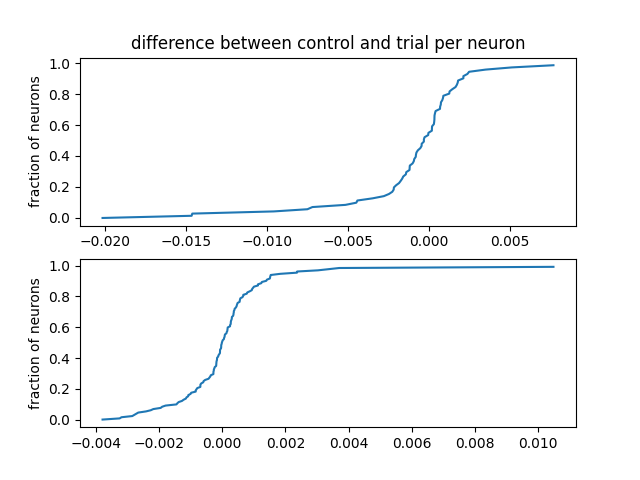

In [8]:
CFA_X = np.sort(session.CFA_neudiff)
RFA_X = np.sort(session.RFA_neudiff)

CFA_Y = np.arange(session.CFA_neudiff.size) / num_CFA
RFA_Y = np.arange(session.RFA_neudiff.size) / num_RFA

fig29, (ax29_0, ax29_1) = plt.subplots(2, 1)
ax29_0.plot(CFA_X, CFA_Y)
ax29_0.set_title('difference between control and trial per neuron')
ax29_0.set_ylabel('fraction of neurons')
ax29_1.set_ylabel('fraction of neurons')
ax29_1.plot(RFA_X, RFA_Y)

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


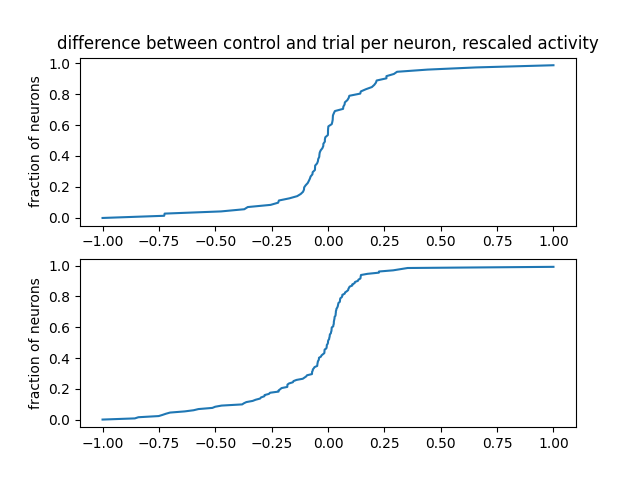

In [9]:
CFA_negs = session.CFA_neudiff[session.CFA_neudiff < 0]
CFA_pos = session.CFA_neudiff[session.CFA_neudiff >= 0]

RFA_negs = session.RFA_neudiff[session.RFA_neudiff < 0]
RFA_pos = session.RFA_neudiff[session.RFA_neudiff >= 0]

CFA_negs_norm = NormalizeData(CFA_negs * -1) * -1
CFA_pos_norm = NormalizeData(CFA_pos)

CFA_X_norm = np.sort(np.concatenate((CFA_negs_norm, CFA_pos_norm)))

RFA_negs_norm = NormalizeData(RFA_negs * -1) * -1
RFA_pos_norm = NormalizeData(RFA_pos)

RFA_X_norm = np.sort(np.concatenate((RFA_negs_norm, RFA_pos_norm)))

fig57, (ax57_0, ax57_1) = plt.subplots(2, 1)
ax57_0.plot(CFA_X_norm, CFA_Y)
ax57_0.set_title('difference between control and trial per neuron, rescaled activity')
ax57_0.set_ylabel('fraction of neurons')
ax57_1.set_ylabel('fraction of neurons')
ax57_1.plot(RFA_X_norm, RFA_Y)



# and now lets look at individual neuron pairs, cross correlograms, show examples of the biggest change in peaks

In [10]:
session.CFA_highFR_trials.shape

(71, 120, 46)

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


Text(0.5, 1.0, 'cfa neuron 0 (source) to rfa neuron 1')

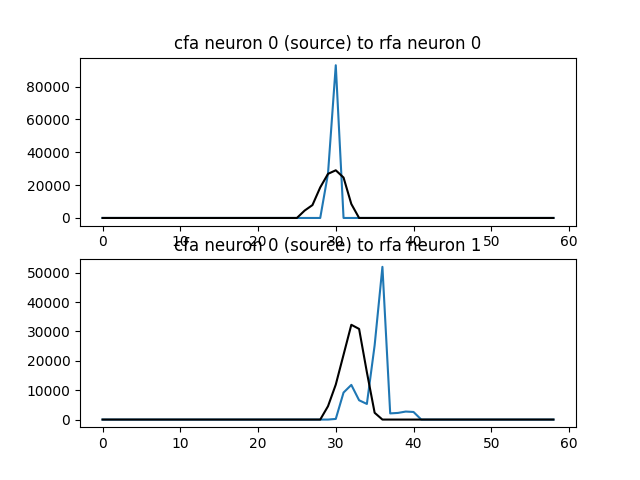

In [11]:
session.CFA_highFR_trialavg = np.average(session.CFA_highFR_trials, axis=2)
session.RFA_highFR_trialavg = np.average(session.RFA_highFR_trials, axis=2)

session.CFA_ctrl_trialavg = np.average(session.CFA_ctrl_trials, axis=2)
session.RFA_ctrl_trialavg = np.average(session.RFA_ctrl_trials, axis=2)

CFA_0_RFA_0_ccg, nada = nap.cross_correlogram(session.CFA_highFR_trialavg[0,:], session.RFA_highFR_trialavg[0,:], binsize = 1/1000, windowsize=30/1000)
CFA_0_RFA_0_ccg_ctrl, nada = nap.cross_correlogram(session.CFA_ctrl_trialavg[0,:], session.RFA_ctrl_trialavg[0,:], binsize = 1/1000, windowsize=30/1000)

CFA_0_RFA_1_ccg, nada = nap.cross_correlogram(session.CFA_highFR_trialavg[0,:], session.RFA_highFR_trialavg[1,:], binsize = 1/1000, windowsize=30/1000)
CFA_0_RFA_1_ccg_ctrl, nada = nap.cross_correlogram(session.CFA_ctrl_trialavg[0,:], session.RFA_ctrl_trialavg[1,:], binsize = 1/1000, windowsize=30/1000)


fig72, (ax72_0, ax72_1) = plt.subplots(2, 1)
ax72_0.plot(CFA_0_RFA_0_ccg)
ax72_0.plot(CFA_0_RFA_0_ccg_ctrl, c='black')
ax72_0.set_title('cfa neuron 0 (source) to rfa neuron 0')

ax72_1.plot(CFA_0_RFA_1_ccg)
ax72_1.plot(CFA_0_RFA_1_ccg_ctrl, c='black')
ax72_1.set_title('cfa neuron 0 (source) to rfa neuron 1')

# next steps, apply cross correlograms as well as other simple functional connectivities to neuron pairs, figure out how to find which pairs are "interesting". Perhaps pairs that both have significant activity changes during opto trials, but similar cross correlations.  

# and then going from neuron pairs to population analysis. PCA built on all non-Opto vs PCA specifically on opto